# Day 5 Project - Sales Driver Analysis

**Objective**: Identify which numerical factors have the strongest relationship with Sales Amount and determine whether those relationships can be used to explain and predict sales.

In [4]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, linregress

import warnings
warnings.filterwarnings(action='ignore')

In [11]:
# Load and inspect the dataset
sales_data = pd.read_csv("Downloads/sales_data.csv")
display(sales_data.head())

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [17]:
# Number of rows and columns
print("Dataset Shape:")
print("Rows:", sales_data.shape[0])
print("Columns:", sales_data.shape[1])

Dataset Shape:
Rows: 1000
Columns: 14


In [19]:
# Column names
print("Column Names:")
print(sales_data.columns.tolist())

Column Names:
['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount', 'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price', 'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [21]:
# Data types
print("Data Types:")
print(sales_data.dtypes)

Data Types:
Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object


In [23]:
# Numerical columns
print("Numerical Columns:")
print(sales_data.select_dtypes(include="number").columns.tolist())

Numerical Columns:
['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']


In [25]:
# Categorical columns
print("Categorical Columns:")
print(sales_data.select_dtypes(include="object").columns.tolist())

Categorical Columns:
['Sale_Date', 'Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [31]:
# Date range
sales_data["Sale_Date"] = pd.to_datetime(sales_data["Sale_Date"])
print("Date Range:")
print("Start Date:", sales_data["Sale_Date"].min())
print("End Date:", sales_data["Sale_Date"].max())

Date Range:
Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [64]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

### Data Quality

In [47]:
# Missing values
print("Missing Values:")
print(sales_data.isnull().sum())

Missing Values:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [51]:
# Duplicate rows
print("Duplicate Rows:")
print("Number of duplicate rows:", sales_data.duplicated().sum())

Duplicate Rows:
Number of duplicate rows: 0


In [53]:
# Unique values in categorical columns
categorical_columns = [
    "Sales_Rep",
    "Region",
    "Product_Category",
    "Customer_Type",
    "Payment_Method",
    "Sales_Channel",
    "Region_and_Sales_Rep"]
print("Unique Values in Categorical Columns:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(sales_data[column].unique())

Unique Values in Categorical Columns:

Sales_Rep:
['Bob' 'David' 'Charlie' 'Eve' 'Alice']

Region:
['North' 'West' 'South' 'East']

Product_Category:
['Furniture' 'Food' 'Clothing' 'Electronics']

Customer_Type:
['Returning' 'New']

Payment_Method:
['Cash' 'Bank Transfer' 'Credit Card']

Sales_Channel:
['Online' 'Retail']

Region_and_Sales_Rep:
['North-Bob' 'West-Bob' 'South-David' 'South-Bob' 'East-Charlie'
 'West-Charlie' 'South-Eve' 'North-Eve' 'West-Eve' 'South-Alice'
 'South-Charlie' 'North-David' 'East-Bob' 'West-David' 'East-Eve'
 'North-Alice' 'East-David' 'West-Alice' 'East-Alice' 'North-Charlie']


In [55]:
# Overall data quality conclusion
missing_values = sales_data.isnull().sum().sum()
duplicate_rows = sales_data.duplicated().sum()

In [59]:
print("DATA QUALITY CONCLUSION")
if missing_values == 0 and duplicate_rows == 0:
    print(
        "The dataset is clean enough for relationship analysis. "
        "There are no missing values or duplicate rows.")
else:
    print("The dataset requires data cleaning before relationship analysis.")

DATA QUALITY CONCLUSION
The dataset is clean enough for relationship analysis. There are no missing values or duplicate rows.


### Part 2: Understand the Target Variable

In [68]:
# SALES SUMMARY
print("Sales Summary")
# Calculate summary statistics
sales_mean = sales_data["Sales_Amount"].mean()
sales_median = sales_data["Sales_Amount"].median()
sales_std = sales_data["Sales_Amount"].std()
sales_min = sales_data["Sales_Amount"].min()
sales_q1 = sales_data["Sales_Amount"].quantile(0.25)
sales_q3 = sales_data["Sales_Amount"].quantile(0.75)
sales_max = sales_data["Sales_Amount"].max()

# Display results
print("Mean:", sales_mean)
print("Median:", sales_median)
print("Standard Deviation:", sales_std)
print("Minimum:", sales_min)
print("Q1:", sales_q1)
print("Q3:", sales_q3)
print("Maximum:", sales_max)

Sales Summary
Mean: 5019.265229999999
Median: 5019.3
Standard Deviation: 2846.7901256682326
Minimum: 100.12
Q1: 2550.2975
Q3: 7507.445000000001
Maximum: 9989.04


Interpretation: Sales Amount averages around ₹5019 per transaction, with the mean and median being almost identical. However, the relatively high standard deviation shows considerable variation in transaction-level sales, with values ranging from approximately ₹100 to ₹9989.

In [73]:
# Sales Distribution Check
print("Skewness:", sales_data["Sales_Amount"].skew())
print("Potential Outliers using IQR:")

Q1 = sales_data["Sales_Amount"].quantile(0.25)
Q3 = sales_data["Sales_Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = sales_data[
    (sales_data["Sales_Amount"] < lower_bound) |
    (sales_data["Sales_Amount"] > upper_bound)]
print("Potential Outliers:", len(outliers))

Skewness: 0.004116099345552753
Potential Outliers using IQR:
Q1: 2550.2975
Q3: 7507.445000000001
IQR: 4957.147500000001
Lower Bound: -4885.423750000002
Upper Bound: 14943.166250000002
Potential Outliers: 0


Sales Distribution


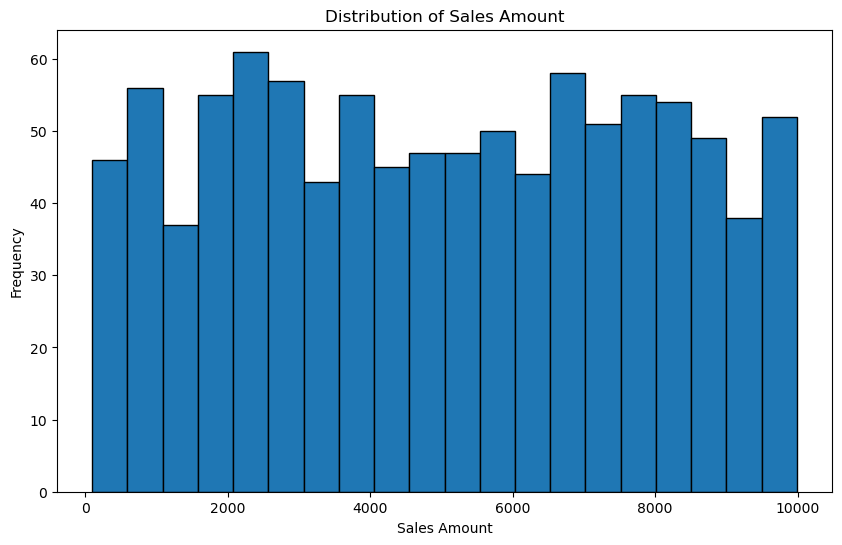

In [71]:
# SALES DISTRIBUTION
print("Sales Distribution")
# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(
    sales_data["Sales_Amount"],
    bins=20,
    edgecolor="black")
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

Interpretation: Sales Amount is approximately symmetric, with negligible skewness and no potential outliers detected by the IQR method.

### Part 2: Understand the Target Variable Conclusion
Sales Amount is centered around ₹5019 and shows considerable variation, but its distribution is approximately symmetric with no detected extreme outliers.

### Part 3 - Identify Potential Sales Drivers

Correlation Matrix

Pearson Correlation Matrix:


,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
Sales_Amount,1.000000,-0.041599,0.009770,0.011812,0.023153
Quantity_Sold,-0.041599,1.000000,0.053888,0.057296,-0.007806
Unit_Cost,0.009770,0.053888,1.000000,0.995056,-0.017741
Unit_Price,0.011812,0.057296,0.995056,1.000000,-0.017027
Discount,0.023153,-0.007806,-0.017741,-0.017027,1.000000


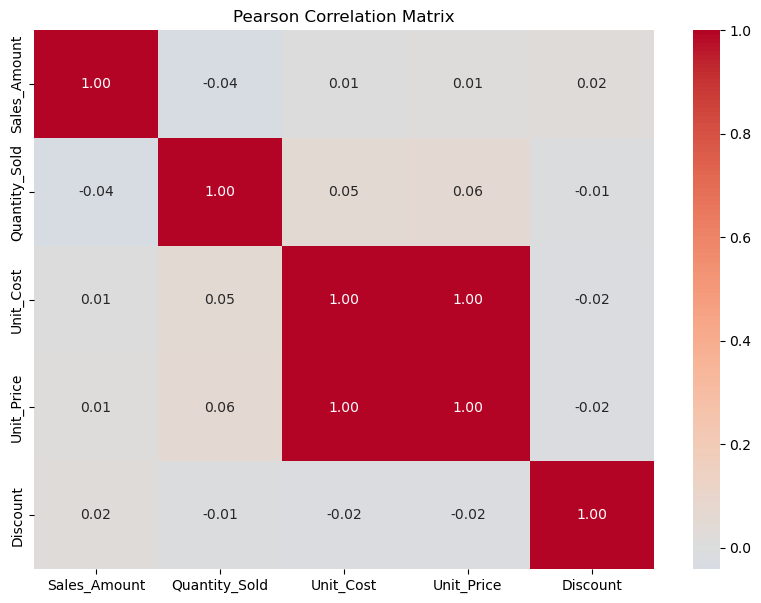

In [76]:
# CORRELATION MATRIX
print("Correlation Matrix")
# Select variables for correlation analysis
correlation_columns = [
    "Sales_Amount",
    "Quantity_Sold",
    "Unit_Cost",
    "Unit_Price",
    "Discount"]
# Calculate Pearson correlation matrix
correlation_matrix = sales_data[correlation_columns].corr(
    method="pearson")
print("\nPearson Correlation Matrix:")
display(correlation_matrix)
# Create correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix")
plt.show()

Interpretation: None of the selected variables shows a meaningful linear relationship with Sales Amount, while Unit Cost and Unit Price are almost perfectly positively correlated with each other.

### Part 3 - Identify Potential Sales Drivers Conclusion
The correlation analysis shows that none of the selected numerical variables is a meaningful linear sales driver, although Unit Cost and Unit Price have an extremely strong correlation with each other (r = 0.995).

### Part 4 - Covariance

In [79]:
# COVARIANCE ANALYSIS
print("Covariance Analysis")
# Variables to compare with Sales Amount
drivers = [
    "Quantity_Sold",
    "Unit_Price",
    "Unit_Cost",
    "Discount"]
# Calculate covariance
covariance_results = []

for driver in drivers:
    covariance = sales_data["Sales_Amount"].cov(
        sales_data[driver])
    covariance_results.append({
        "Sales Driver": driver,
        "Covariance": covariance})
# Create results table
covariance_df = pd.DataFrame(covariance_results)
display(covariance_df)

Covariance Analysis


,Sales Driver,Covariance
0,Quantity_Sold,-1676.748896
1,Unit_Price,47729.239363
2,Unit_Cost,39433.517979
3,Discount,5.747411


Interpretation: Sales Amount moves oppositely with Quantity Sold but in the same direction as Unit Price, Unit Cost and Discount. However, covariance magnitudes should not be directly compared because the variables have different scales.

### Part 4 - Covariance Conclusion
Covariance shows the direction of co-movement between Sales Amount and the potential drivers, but Pearson correlation is more useful for comparing relationship strength across variables.

### Part 5 - Sales & Quantity Sold

Quantity Sold vs Sales Amount


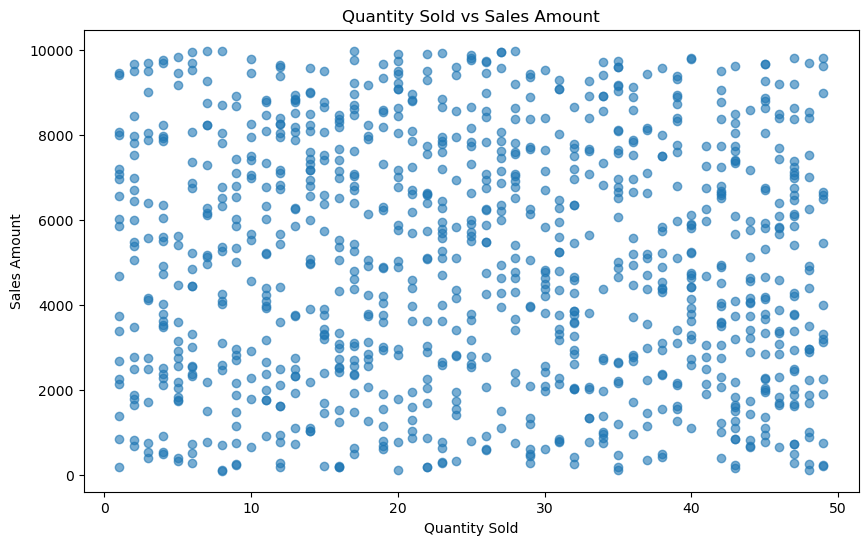

In [82]:
# VISUAL RELATIONSHIP
print("Quantity Sold vs Sales Amount")
plt.figure(figsize=(10, 6))
plt.scatter(sales_data["Quantity_Sold"], sales_data["Sales_Amount"], alpha=0.6)
plt.title("Quantity Sold vs Sales Amount")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales Amount")
plt.show()

Interpretation: Quantity Sold and Sales Amount show no clear linear pattern; the points are widely scattered, indicating a very weak negative relationship with no obvious outliers.

In [85]:
# PEARSON CORRELATION
print("Pearson Correlation")
# Calculate Pearson correlation
pearson_r, p_value = pearsonr(sales_data["Quantity_Sold"], sales_data["Sales_Amount"])
print("Pearson Correlation (r):", pearson_r)
# Determine direction
if pearson_r > 0:
    direction = "Positive"
elif pearson_r < 0:
    direction = "Negative"
else:
    direction = "No Direction"
# Determine strength
if abs(pearson_r) >= 0.70:
    strength = "Strong"
elif abs(pearson_r) >= 0.30:
    strength = "Moderate"
else:
    strength = "Weak"
print("Direction:", direction)
print("Strength:", strength)

Pearson Correlation
Pearson Correlation (r): -0.04159870498082681
Direction: Negative
Strength: Weak


InterpretationQuantity Sold has a very weak negative correlation with Sales Amount (r = −0.042), indicating virtually no meaningful linear relationship between the two variables.

### Part 5 - Sales & Quantity Sold Conclusion
Both the scatter plot and Pearson correlation indicate that Quantity Sold is not a meaningful linear driver of Sales Amount in this dataset.

### Part 6 - Simple Linear Regression

In [88]:
# SIMPLE LINEAR REGRESSION
print("Simple Linear Regression")
# Independent variable (X)
X = sales_data["Quantity_Sold"]
# Dependent variable (Y)
Y = sales_data["Sales_Amount"]
# Build regression model
regression_result = linregress(X, Y)
# Extract results
intercept = regression_result.intercept
slope = regression_result.slope
r_squared = regression_result.rvalue ** 2
# Display results
print("Intercept (β₀):", intercept)
print("Slope (β₁):", slope)
print("R²:", r_squared)
# Regression equation
print("\nRegression Equation:")
print(
    f"Sales_Amount = {intercept:.2f} + "
    f"({slope:.2f} × Quantity_Sold)")

Simple Linear Regression
Intercept (β₀): 5231.32881982759
Slope (β₁): -8.363777946266659
R²: 0.001730452256081863

Regression Equation:
Sales_Amount = 5231.33 + (-8.36 × Quantity_Sold)


Business Interpretation: Quantity Sold has virtually no predictive power for Sales Amount, with an R² of only 0.17%, so this regression model is not useful for predicting sales.

Regression Residual Analysis
Residual Mean: 7.785274647176266e-13
Residual Standard Deviation: 2844.325941970815
Minimum Residual: -5064.298596257458
Maximum Residual: 4991.816299539476


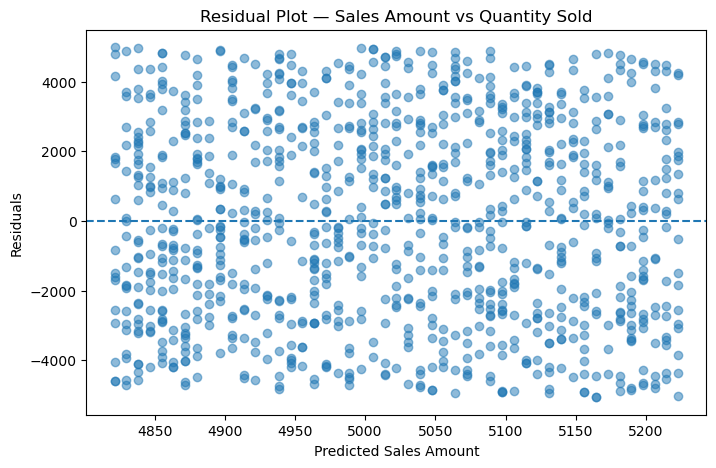

In [185]:
# REGRESSION RESIDUAL ANALYSIS
print("Regression Residual Analysis")
# Predicted Sales Amount
predicted_sales = intercept + (slope * X)
# Calculate residuals
residuals = Y - predicted_sales
# Display residual statistics
print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())
# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(predicted_sales, residuals, alpha=0.5)
# Reference line at zero
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Sales Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot — Sales Amount vs Quantity Sold")
plt.show()

In [189]:
# MULTIPLE LINEAR REGRESSION
import statsmodels.api as sm
print("Multiple Linear Regression")
# Independent variables
X_multiple = sales_data[
    ["Quantity_Sold", "Discount", "Unit_Price", "Unit_Cost"]]
# Dependent variable
Y = sales_data["Sales_Amount"]
# Add intercept
X_multiple = sm.add_constant(X_multiple)
# Build multiple regression model
multiple_model = sm.OLS(Y, X_multiple).fit()
# Display model results
print(multiple_model.summary())
# Extract R²
multiple_r_squared = multiple_model.rsquared

print("\nMultiple Regression R²:", multiple_r_squared)
print(f"Multiple Regression R² (%): {multiple_r_squared * 100:.2f}%")

Multiple Linear Regression
                            OLS Regression Results                            
Dep. Variable:           Sales_Amount   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7263
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.574
Time:                        17:28:32   Log-Likelihood:                -9370.9
No. Observations:                1000   AIC:                         1.875e+04
Df Residuals:                     995   BIC:                         1.878e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4942

Interpretation: The residual analysis and multiple regression both confirm that these numerical variables provide very limited ability to explain or predict Sales Amount, so other business factors should be investigated.

In [94]:
# SALES PREDICTION
print("Sales Prediction")
# Quantities for prediction
quantities = [5, 10, 20]
# Calculate predicted sales
predicted_values = [
    intercept + slope * quantity
    for quantity in quantities]
# Create prediction table
prediction_df = pd.DataFrame({
    "Quantity_Sold": quantities,
    "Predicted_Sales_Amount": predicted_values})
display(prediction_df)

Sales Prediction


,Quantity_Sold,Predicted_Sales_Amount
0,5,5189.509930
1,10,5147.691040
2,20,5064.053261


Interpretation: For 10 units sold, the model predicts sales of approximately ₹5147.69, but this prediction has very limited reliability because the model explains only 0.17% of sales variation.

### Part 6 - Simple Linear Regression Conclusion
The regression analysis confirms that Quantity Sold has almost no predictive power for Sales Amount, making it an ineffective standalone predictor in this dataset.

### Part 7 - Compare Other Sales Drivers

Unit Price vs Sales
Pearson Correlation (r): 0.011812023736311177
Direction: Positive
Strength: Weak


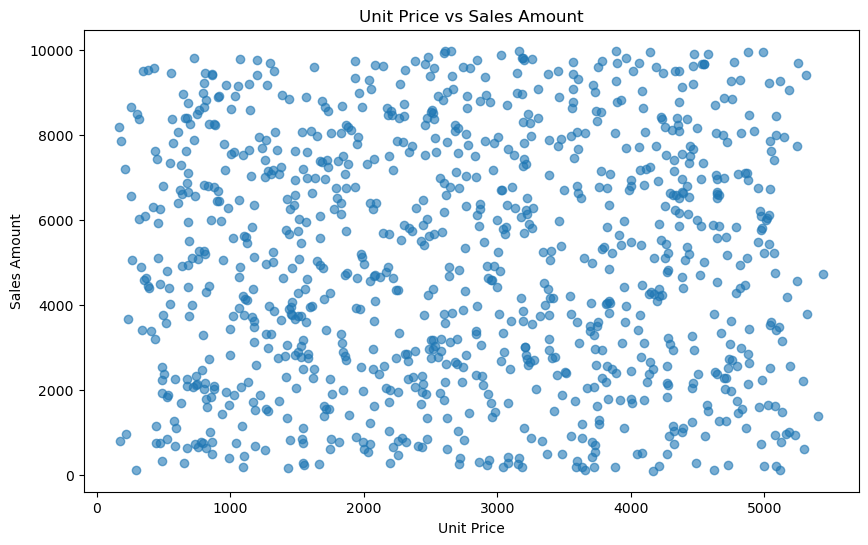

In [97]:
# UNIT PRICE VS SALES
print("Unit Price vs Sales")
# Calculate Pearson correlation
unit_price_r, unit_price_p = pearsonr(sales_data["Unit_Price"], sales_data["Sales_Amount"])
print("Pearson Correlation (r):", unit_price_r)
# Determine direction
if unit_price_r > 0:
    direction = "Positive"
elif unit_price_r < 0:
    direction = "Negative"
else:
    direction = "No Direction"
# Determine strength
if abs(unit_price_r) >= 0.70:
    strength = "Strong"
elif abs(unit_price_r) >= 0.30:
    strength = "Moderate"
else:
    strength = "Weak"

print("Direction:", direction)
print("Strength:", strength)
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(sales_data["Unit_Price"], sales_data["Sales_Amount"], alpha=0.6)
plt.title("Unit Price vs Sales Amount")
plt.xlabel("Unit Price")
plt.ylabel("Sales Amount")
plt.show()

Interpretation: Unit Price has an extremely weak positive correlation with Sales Amount (r = 0.012) and the scattered plot shows no meaningful linear relationship.

In [101]:
# UNIT COST VS SALES
print("Unit Cost vs Sales")
# Calculate Pearson correlation
unit_cost_r, unit_cost_p = pearsonr(
    sales_data["Unit_Cost"],
    sales_data["Sales_Amount"])
print("Pearson Correlation (r):", unit_cost_r)
# Determine direction
if unit_cost_r > 0:
    direction = "Positive"
elif unit_cost_r < 0:
    direction = "Negative"
else:
    direction = "No Direction"
# Determine strength
if abs(unit_cost_r) >= 0.70:
    strength = "Strong"
elif abs(unit_cost_r) >= 0.30:
    strength = "Moderate"
else:
    strength = "Weak"

print("Direction:", direction)
print("Strength:", strength)

Unit Cost vs Sales
Pearson Correlation (r): 0.009769512193445176
Direction: Positive
Strength: Weak


Interpretation: Unit Cost has an extremely weak positive correlation with Sales Amount (r = 0.010), indicating virtually no meaningful linear relationship.

In [104]:
# DISCOUNT VS SALES
print("Discount vs Sales")
# Calculate Pearson correlation
discount_r, discount_p = pearsonr(
    sales_data["Discount"],
    sales_data["Sales_Amount"])
print("Pearson Correlation (r):", discount_r)
# Determine direction
if discount_r > 0:
    direction = "Positive"
elif discount_r < 0:
    direction = "Negative"
else:
    direction = "No Direction"
# Determine strength
if abs(discount_r) >= 0.70:
    strength = "Strong"
elif abs(discount_r) >= 0.30:
    strength = "Moderate"
else:
    strength = "Weak"

print("Direction:", direction)
print("Strength:", strength)

Discount vs Sales
Pearson Correlation (r): 0.023152703341197584
Direction: Positive
Strength: Weak


Interpretation: Discount has an extremely weak positive correlation with Sales Amount (r = 0.023), indicating virtually no meaningful linear relationship between discount and sales.

### Part 7 - Compare Other Sales Drivers Conclusion
Unit Price, Unit Cost, and Discount all show a very weak positive relationship with Sales Amount. Among them, Discount has the strongest correlation (r = 0.023), followed by Unit Price (r = 0.012) and Unit Cost (r = 0.010). However, all three relationships are too weak to be considered meaningful sales drivers in this dataset.

### Part 8 - Sales Driver Comparison

In [139]:
# SALES DRIVER COMPARISON
print("Sales Driver Comparison")
# Correlations calculated earlier
driver_correlations = {
    "Quantity Sold": pearson_r,
    "Unit Price": unit_price_r,
    "Unit Cost": unit_cost_r,
    "Discount": discount_r}
# Create comparison table
driver_df = pd.DataFrame([{
        "Sales Driver": driver,
        "Pearson r": correlation,
        "Direction": "Positive" if correlation > 0 else "Negative",
        "Absolute |r|": abs(correlation)}
    for driver, correlation in driver_correlations.items()])
# Rank by absolute correlation
driver_df = driver_df.sort_values(by="Absolute |r|", ascending=False).reset_index(drop=True)
# Add rank
driver_df.insert(0, "Rank", range(1, len(driver_df) + 1))
display(driver_df)

Sales Driver Comparison


,Rank,Sales Driver,Pearson r,Direction,Absolute |r|
0,1,Quantity Sold,-0.041599,Negative,0.041599
1,2,Discount,0.023153,Positive,0.023153
2,3,Unit Price,0.011812,Positive,0.011812
3,4,Unit Cost,0.009770,Positive,0.009770


Interpretation: Quantity Sold has the strongest correlation with Sales Amount, but the relationship is still very weak and negative (r = -0.042).

### Part 8 - Sales Driver Comparison Conclusion
Overall, none of the four variables shows a meaningful linear relationship with Sales Amount, with Quantity Sold being the strongest but still very weak.

### Part 9 - Correlation ≠ Causation

In [145]:
# Correlation ≠ Causation
correlations = {
    "Quantity Sold": -0.041599,
    "Discount": 0.023153,
    "Unit Price": 0.011812,
    "Unit Cost": 0.009770}
for variable, r in correlations.items():
    print(f"{variable}: r = {r:.4f}")

print("\nInterpretation:")
print("All correlation values are very close to 0, indicating extremely weak")
print("linear relationships with Sales Amount.")
print("Therefore, these correlations do not prove that any of these variables")
print("causes changes in Sales Amount.")

Quantity Sold: r = -0.0416
Discount: r = 0.0232
Unit Price: r = 0.0118
Unit Cost: r = 0.0098

Interpretation:
All correlation values are very close to 0, indicating extremely weak
linear relationships with Sales Amount.
Therefore, these correlations do not prove that any of these variables
causes changes in Sales Amount.


### Part 9 - Correlation ≠ Causation Conclusion
The correlation results show very weak relationships with Sales Amount. Therefore, correlation alone cannot establish that any of these variables causes changes in sales. Other factors may influence sales, so these relationships should be interpreted as associations, not causal effects.

### Part 10 - Management Analysis

In [150]:
# MANAGEMENT ANALYSIS
print("Management Analysis")
# Calculate Pearson correlations with Sales Amount
drivers = [
    "Quantity_Sold",
    "Discount",
    "Unit_Price",
    "Unit_Cost"]
correlations = sales_data[drivers + ["Sales_Amount"]].corr()["Sales_Amount"].drop("Sales_Amount")
# Sort by absolute correlation strength
driver_comparison = correlations.abs().sort_values(ascending=False)

print("Sales Driver Correlations:")
print(correlations.sort_values(key=abs, ascending=False))

print("\nStrongest Sales Driver:")
strongest_driver = correlations.abs().idxmax()
strongest_r = correlations[strongest_driver]

print(f"{strongest_driver}: r = {strongest_r:.4f}")

Management Analysis
Sales Driver Correlations:
Quantity_Sold   -0.041599
Discount         0.023153
Unit_Price       0.011812
Unit_Cost        0.009770
Name: Sales_Amount, dtype: float64

Strongest Sales Driver:
Quantity_Sold: r = -0.0416


Business Interpretation: None of the four variables is a meaningful linear driver of Sales Amount, so management should investigate other factors to understand sales performance.

In [163]:
# MANAGEMENT RECOMMENDATION
print("Management Recommendation")
# Identify the strongest numerical driver
strongest_driver = correlations.abs().idxmax()
strongest_r = correlations[strongest_driver]

print(f"Strongest numerical driver: {strongest_driver}")
print(f"Pearson correlation: {strongest_r:.4f}")

print("\nRecommendation:")
print("The numerical variables analysed show very weak relationships with Sales Amount. Management should therefore investigate other business factors")
print("such as Region, Product Category, Customer Type, Sales Channel and Sales Rep.")

Management Recommendation
Strongest numerical driver: Quantity_Sold
Pearson correlation: -0.0416

Recommendation:
The numerical variables analysed show very weak relationships with Sales Amount. Management should therefore investigate other business factors
such as Region, Product Category, Customer Type, Sales Channel and Sales Rep.


In [167]:
# FINAL BUSINESS CONCLUSION
print("Final Business Conclusion")

print("Final Findings:")
print("- The analysed numerical variables show very weak relationships with Sales Amount.")
print("- Quantity Sold has the strongest correlation, but it is still extremely weak (r = -0.0416).")
print("- The regression model using Quantity Sold explains only 0.17% of the variation in Sales Amount.")
print("- Therefore, these numerical variables alone cannot effectively explain or predict Sales Amount.")

print("\nBusiness Recommendation:")
print("Management should investigate categorical and other business factors such as Region, Product Category, Customer Type,")
print("Sales Channel and Sales Rep to better understand sales performance.")

Final Business Conclusion
Final Findings:
- The analysed numerical variables show very weak relationships with Sales Amount.
- Quantity Sold has the strongest correlation, but it is still extremely weak (r = -0.0416).
- The regression model using Quantity Sold explains only 0.17% of the variation in Sales Amount.
- Therefore, these numerical variables alone cannot effectively explain or predict Sales Amount.

Business Recommendation:
Management should investigate categorical and other business factors such as Region, Product Category, Customer Type,
Sales Channel and Sales Rep to better understand sales performance.


## Limitations & Next Steps
### Limitations
 - The analysis mainly focused on **numerical variables**.
 - The tested variables showed **very weak relationships with Sales Amount**.
 - The multiple regression explained only **0.29%** of sales variation.
 - **Correlation does not prove causation**, so the results cannot establish cause-and-effect relationships.
 - The analysis did not fully explore **categorical business factors**.
### Next Steps
 - Analyse **Region** to identify regional sales patterns.
 - Analyse **Product Category** to find high- and low-performing categories.
 - Compare **Customer Type** to understand different customer segments.
 - Analyse **Sales Channel** to identify better-performing channels.
 - Compare **Sales Rep** performance.
 - Build a broader model using the most relevant variables and compare its predictive performance.

**Final takeaway**: The current analysis shows that the tested numerical variables are not sufficient to explain Sales Amount, creating an opportunity for deeper analysis of categorical and business-specific factors.

#### Key Findings / Issues
 - **No strong sales driver** was found among the numerical variables.
 - **Quantity Sold** had the strongest relationship, but it was still **very weak**.
 - **Discount, Unit Price and Unit Cost** also had almost no relationship with Sales Amount.
 - The regression model had **very low predictive power (R² = 0.17%)**.
 - **Correlation does not mean causation**, so we cannot say any variable causes changes in sales.
 - The main issue is that **Sales Amount is not well explained by these numerical variables**.
 - We should next investigate **Region, Product Category, Customer Type, Sales Channel and Sales Rep**.

#### The biggest takeaway

The key issue wasn't that the dataset failed - it was that our tested numerical variables failed to explain Sales Amount. This is itself an important business finding and tells us where the next analysis should go.

In [174]:
# MANAGEMENT SUMMARY
print("=" * 70)
print("Management Summary")
print("=" * 70)

print("\n1. Strongest Relationship with Sales Amount:")
print("Quantity Sold has the strongest relationship with Sales Amount, with Pearson correlation r = -0.0416.")

print("\n2. Direction and Strength:")
print("The relationship is negative and extremely weak, as the correlation is very close to 0.")

print("\n3. Regression Model:")
print("The regression model shows that each additional unit ofQuantity Sold is associated with an estimated ₹8.36 decrease in Sales Amount. ")
print("However, the relationship is extremely weak.")

print("\n4. R² Interpretation:")
print("R² = 0.00173, meaning Quantity Sold explains only 0.17% of the variation in Sales Amount.")
print("Therefore, the model has very little predictive power.")

print("\n5. Correlation vs Causation:")
print("Correlation cannot be interpreted as causation here.")
print("The weak relationship does not prove that Quantity Sold causes changes in Sales Amount.")

print("\n6. Further Investigation:")
print("Management should investigate Region, Product Category, Customer Type, Sales Channel and Sales Rep.")

print("\n7. Practical Recommendations:")
print("i. Analyse categorical business factors to identify meaningful sales patterns.")
print("ii. Avoid relying on Quantity Sold alone for sales prediction and consider multiple relevant business factors.")

print("\nOverall Management Conclusion:")
print("None of the numerical variables tested is a meaningful linear driver of Sales Amount. Management should focus")
print("on broader business factors for better sales analysis and decision-making.")

Management Summary

1. Strongest Relationship with Sales Amount:
Quantity Sold has the strongest relationship with Sales Amount, with Pearson correlation r = -0.0416.

2. Direction and Strength:
The relationship is negative and extremely weak, as the correlation is very close to 0.

3. Regression Model:
The regression model shows that each additional unit ofQuantity Sold is associated with an estimated ₹8.36 decrease in Sales Amount. 
However, the relationship is extremely weak.

4. R² Interpretation:
R² = 0.00173, meaning Quantity Sold explains only 0.17% of the variation in Sales Amount.
Therefore, the model has very little predictive power.

5. Correlation vs Causation:
Correlation cannot be interpreted as causation here.
The weak relationship does not prove that Quantity Sold causes changes in Sales Amount.

6. Further Investigation:
Management should investigate Region, Product Category, Customer Type, Sales Channel and Sales Rep.

7. Practical Recommendations:
i. Analyse categori

In [180]:
print("=" * 60)
print("DAY 5 - PROBABILITY + CORRELATION + REGRESSION")
print("PROJECT COMPLETED ✓")
print("=" * 60)

print("\nFINAL TAKEAWAY:")
print("This project demonstrated how statistical analysis can be used to move from raw business data"
      "to evidence-based sales insights and management decisions.")

print("\nThe analysis highlights the importance of testing relationships statistically rather than assuming"
      "that business variable is an important driver of sales.")

print("\nEND OF PROJECT ✓")
print("=" * 60)

DAY 5 - PROBABILITY + CORRELATION + REGRESSION
PROJECT COMPLETED ✓

FINAL TAKEAWAY:
This project demonstrated how statistical analysis can be used to move from raw business datato evidence-based sales insights and management decisions.

The analysis highlights the importance of testing relationships statistically rather than assumingthat business variable is an important driver of sales.

END OF PROJECT ✓
